# 💾 **Downloading Data**

In [4]:
# ⚙️ Run this cell only once to download and save the data.
# After this, you can skip it and directly load the CSV files.

import yfinance as yf

start_date = "2010-06-01"
end_date = "2020-06-30"

# Download data (each index in its own DataFrame)
sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
nikkei_data = yf.download('^N225',  start=start_date, end=end_date)

# Save the data as CSV files
sp500_data.to_csv("sp500_data.csv")
dax_data.to_csv("dax_data.csv")
nikkei_data.to_csv("nikkei_data.csv")


/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_2235/2253404788.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_2235/2253404788.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/2h/wg2tcsjx2dv4v71hht7r1js00000gn/T/ipykernel_2235/2253404788.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nikkei_data = yf.download('^N225',  start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


# ⚙️ Setup: Import Libraries, Load Data, and Define Functions

If you already have the historical data for the four indices saved as CSV files, you can **skip the previous cell** and start running from here.


In [5]:
# Importing required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import joblib # for saving the parameter of linear regression model
from statsmodels.tsa.stattools import adfuller, kpss

from fracdiff.sklearn import Fracdiff

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# Importing functions from mypackage
from mypackage_utils import *


# Loading Data and Visualizing Time Series

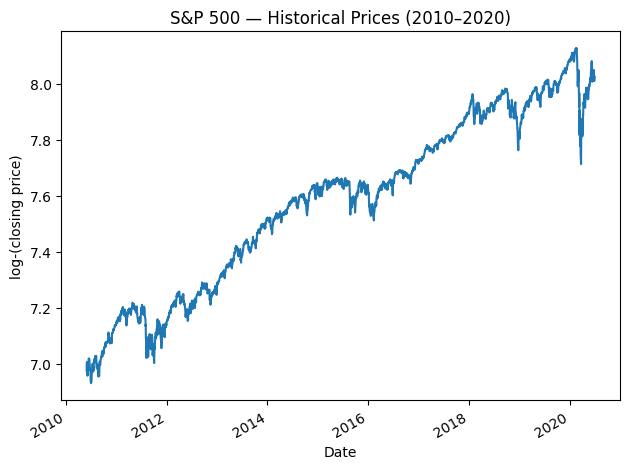

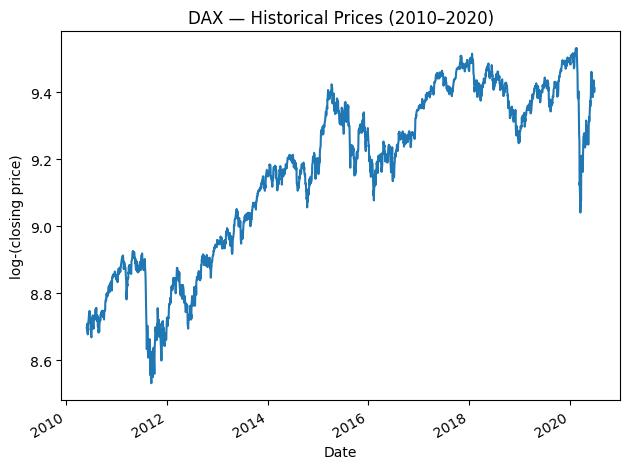

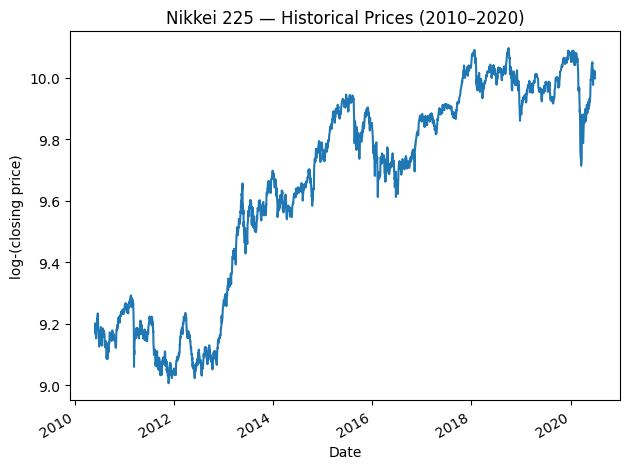

In [6]:
# We take the log of the prices, since when differentiated, they approximate the returns
sp500 = np.log(np.maximum(reading_file("sp500_data.csv").astype(float), 1e-8)) 
dax = np.log(np.maximum(reading_file("dax_data.csv").astype(float), 1e-8))         
nikkei = np.log(np.maximum(reading_file("nikkei_data.csv").astype(float), 1e-8))    

# Plot each index
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    df["Close"].plot(title=f"{name} — Historical Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("log-(closing price)")
    plt.tight_layout()
    plt.show()


In the following, we analyze the **stationarity** of the time series by applying **unit root tests** such as *ADF* and *KPSS*.


In [7]:
results = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close"])
    results.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table = pd.DataFrame(results, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-1.25 (0.65),122.17 (0.01)
DAX,-1.76 (0.40),110.00 (0.01)
Nikkei 225,-1.19 (0.68),108.86 (0.01)


## Stationarity test (ADF)

We use the **Augmented Dickey–Fuller (ADF)** test, a unit-root test that extends the
classical **Dickey–Fuller (DF)** framework. The DF test is derived under an AR(p)
data-generating process and tests whether the autoregressive root equals one.  
The **ADF** augments the DF regression with **lagged first differences**.

### Specification used in this notebook
With `regression='c'` (intercept only), `maxlag = 1`, and automatic lag selection
(`autolag`), the estimated regression is

$\Delta y_t \;=\; \alpha \;+\; \beta\,y_{t-1} \;+\; \gamma_1\,\Delta y_{t-1} \;+\; Z_t,$

where $\alpha$ is a drift term, $\beta$ is the coefficient associated with the
(unit-root) level term, $\gamma_1$ controls short-run dynamics, and
$Z_t$ is white noise.

- **Null hypothesis** $H_0:\ \beta = 0$  
  (equivalently, the AR root is 1 ⇒ the series has a **unit root** ⇒ **non-stationary**).
- **Alternative** $H_1:\ \beta < 0$  
(the series is **stationary** around a constant).

> With `maxlag = 1`, `autolag` effectively chooses to include  1 lag
> of $\Delta y$; the selected specification is the one reported above.

### Interpreting the p-value
- **Small p-value** (e.g., ≤ 0.05): reject $H_0$ ⇒ evidence **against** a unit root
  (stationarity under the chosen deterministic terms).
- **Large p-value**: do **not** reject $H_0$ ⇒ results consistent with a unit root
  (non-stationarity).

# Differentiating the time series

In what follows we apply **integer** and **fractional** differencing to obtain
(time-)**stationary** series better suited for forecasting.

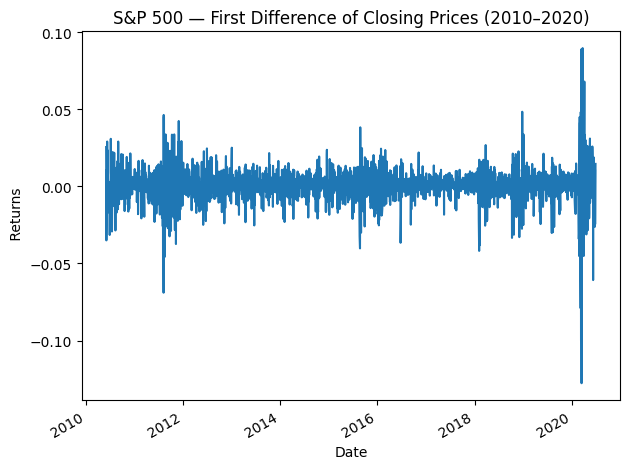

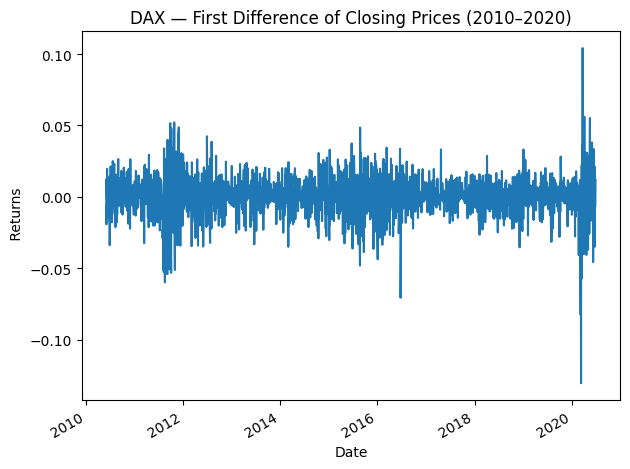

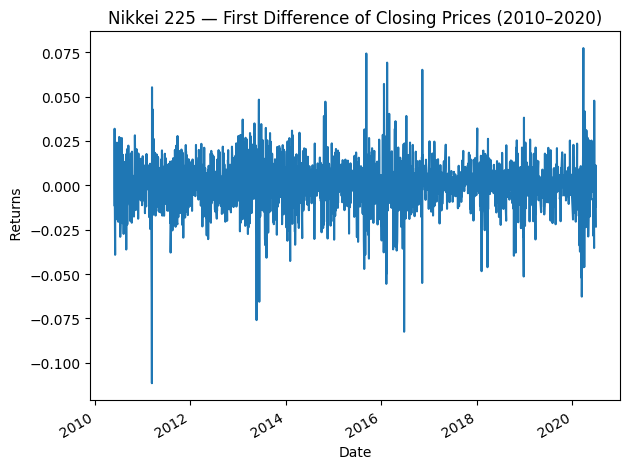

In [8]:
# Integer differencing (d = 1) 
# We can also think at the integer differeciated series as the returns series

base_cols = ['Open','High','Low','Close']

for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # Add first difference columns to the dataframe
    df = add_frac_diff_column(df, order_diff=1, cols=base_cols, mode="integer")
    df["Close_d"].plot(title=f"{name} — First Difference of Closing Prices (2010–2020)")
    plt.xlabel("Date")
	# Return since we are differentiating the log-prices
    plt.ylabel(" Returns")
    plt.tight_layout()
    plt.show()

In [9]:
# ADF and KPSS on the differenced series (quick check) 
results_diff = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_d"])
    results_diff.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_diff = pd.DataFrame(results_diff, columns=["Stock index", "ADF ", "KPSS "]).set_index("Stock index")
display(table_diff.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-35.15 (0.00),0.04 (0.10)
DAX,-34.88 (0.00),0.05 (0.10)
Nikkei 225,-34.25 (0.00),0.06 (0.10)


As expected, the **first difference** (d = 1) yields (near-)stationary series. The ADF statistic typically moves from around **−1/−2** to **−20/−30**, indicating strong evidence against a unit root. This suggests that a **fractional** order might suffice to reach stationarity while **preserving more memory** than d = 1.


# Fractional Differentiation

We now apply **fractional differencing** to the closing prices.  
Our goal is to obtain (near-)stationarity while retaining as much memory of the original series as possible.  


## Finding the best order of differentiation

We now test a range of fractional orders $ d \in \{0.1, 0.2, \ldots, 0.9\} $ to identify the smallest value that yields (near-)stationarity for each index. The goal is to analyze how the ADF statistic varies with the order of fractional differencing, in order to identify the optimal degree ( $ d^* $ ) that achieves stationarity.
The ADF test is computed only on the fractional differentiated log-(closing price), which serves as a representative indicator of stationarity.
Once the optimal order ( $ d^* $ ) is determined, the same value is then applied to all features (Open, High, Low, Close) that will be used as inputs to our model.

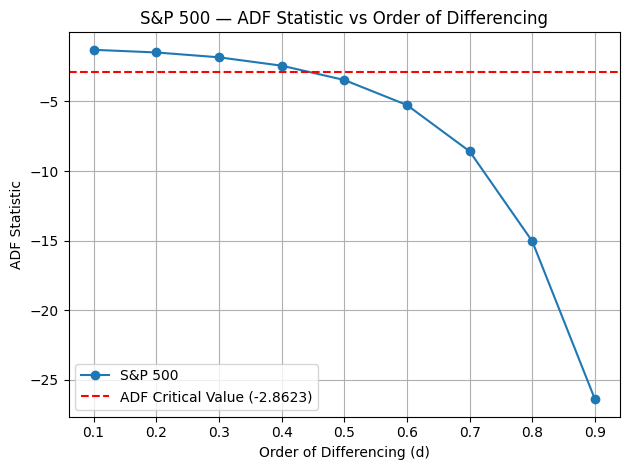

Estimated order of stationarity for S&P 500: ~ 0.442


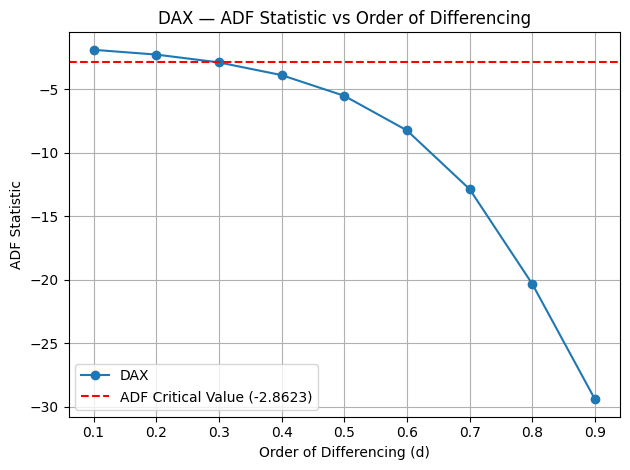

Estimated order of stationarity for DAX: ~ 0.294


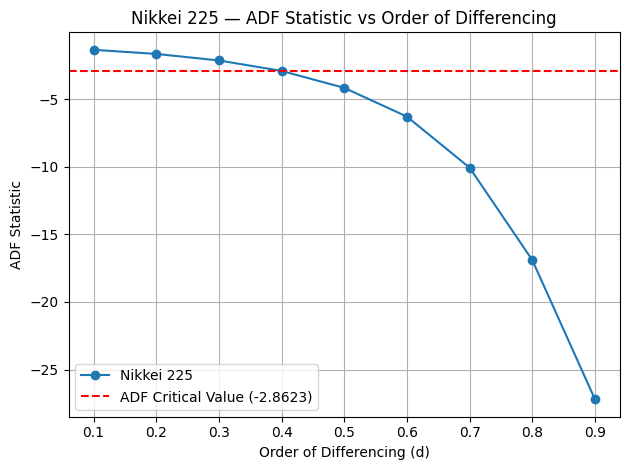

Estimated order of stationarity for Nikkei 225: ~ 0.396


In [10]:
# Plot the ADF results vs order of differentiation
frac_orders = []
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for name, df in {
	"S&P 500": sp500,
	"DAX": dax,
	"Nikkei 225": nikkei,
}.items():
	cval = -2.8623  # ADF critical value at 5% for n > 1000
	rows = sweep_fractional_orders(df, d_grid)
	d_values = [r['d'] for r in rows]
	adf_stats = [r['adf_stat'] for r in rows]
	plt.title(f"{name} — ADF Statistic vs Order of Differencing")
	plt.plot(d_values, adf_stats, marker='o', label=name)
	plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
	plt.xlabel("Order of Differencing (d)")
	plt.ylabel("ADF Statistic")
	plt.legend()
	plt.grid()
	plt.tight_layout()
	plt.show()
	# Intersection between ADF stats and critical value
	# find first crossing where ADF goes from > cval to <= cval
	d_values  = np.asarray(d_values, dtype=float)
	adf_stats = np.asarray(adf_stats, dtype=float)
	mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
	idx = np.where(mask)[0]
	i = idx[0]
	# linear interpolation
	d1, d2 = d_values[i], d_values[i+1]
	a1, a2 = adf_stats[i], adf_stats[i+1]
	d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
	print(f"Estimated order of stationarity for {name}: ~ {d_star:.3f}")
	frac_orders.append((name, d_star))

In [11]:
# Given fractional orders 
frac_orders = dict(frac_orders)

sp500 = add_frac_diff_column(sp500, order_diff=frac_orders["S&P 500"],  cols=base_cols, mode="fractional")

dax   = add_frac_diff_column(dax,   order_diff=frac_orders["DAX"],    cols=base_cols, mode="fractional")

nikkei = add_frac_diff_column(nikkei, order_diff=frac_orders["Nikkei 225"], cols=base_cols, mode="fractional")

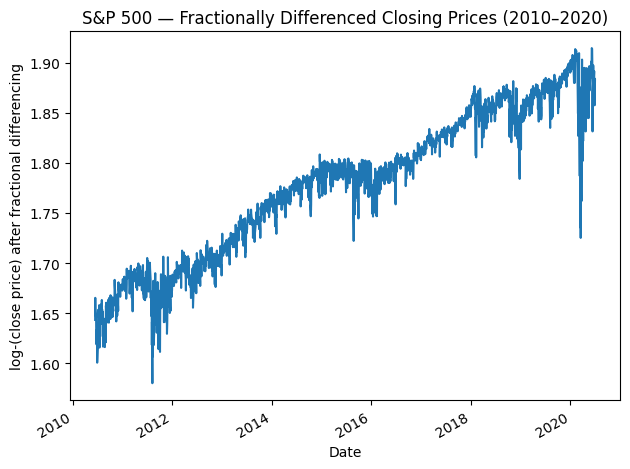

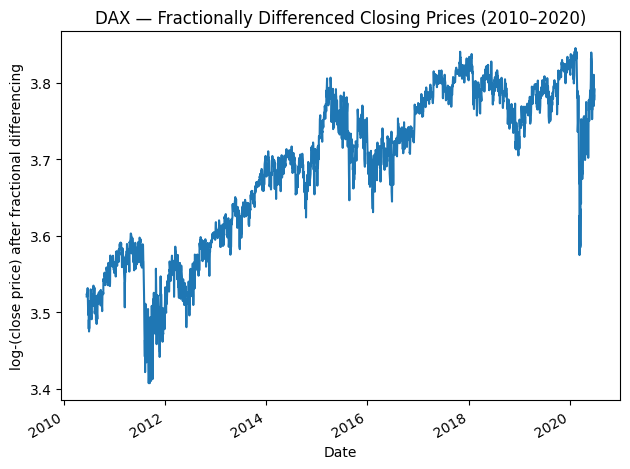

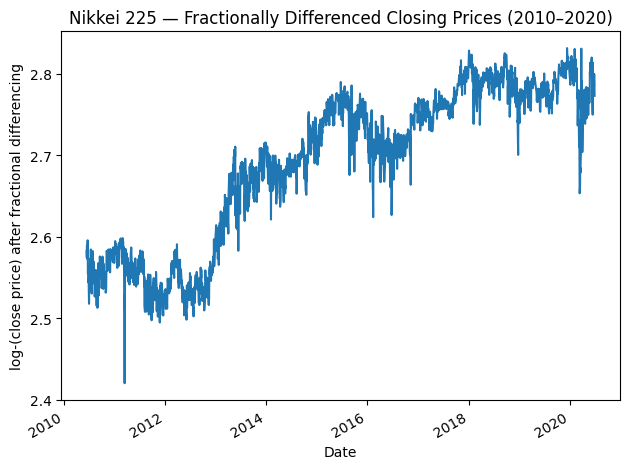

In [12]:
# Plot fractionally differenced series
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # I would suggest to skip first few NaNs due to differencing for better visualization
    df["Close_fd"].plot(title=f"{name} — Fractionally Differenced Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("log-(close price) after fractional differencing")
    plt.tight_layout()
    plt.show()

In [13]:
# Stationarity tests on fractionally differenced series 
results_fd = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_fd"])  
    results_fd.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_fd = pd.DataFrame(results_fd, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table_fd.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-2.80 (0.06),119.71 (0.01)
DAX,-2.85 (0.05),107.62 (0.01)
Nikkei 225,-2.86 (0.05),106.20 (0.01)


### Original vs Fractional differentiated plot

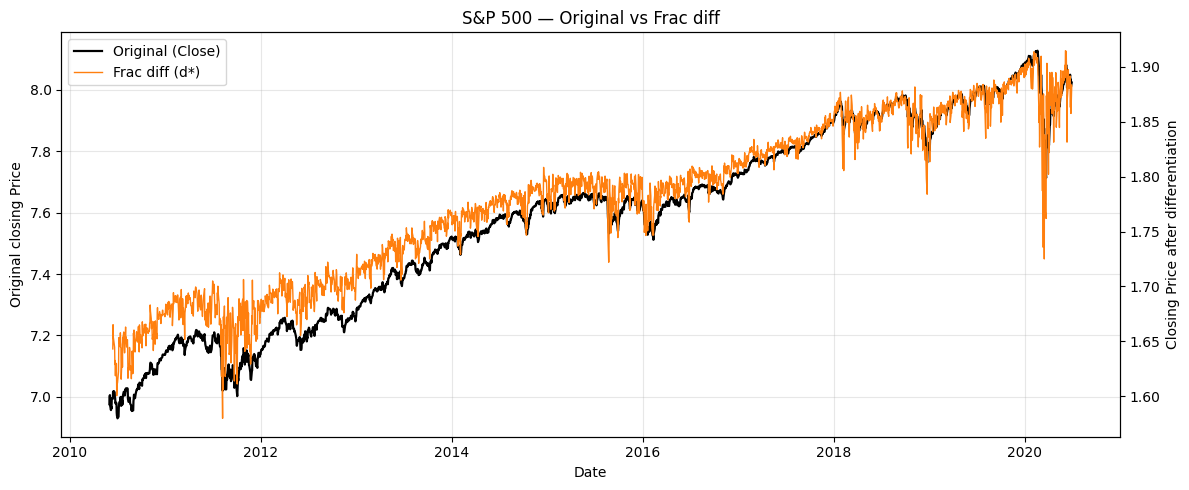

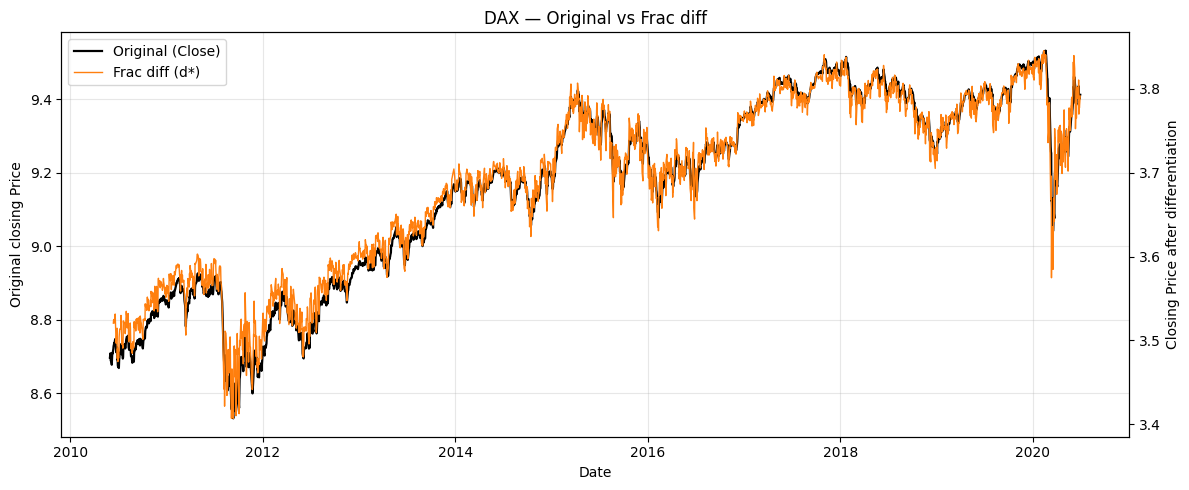

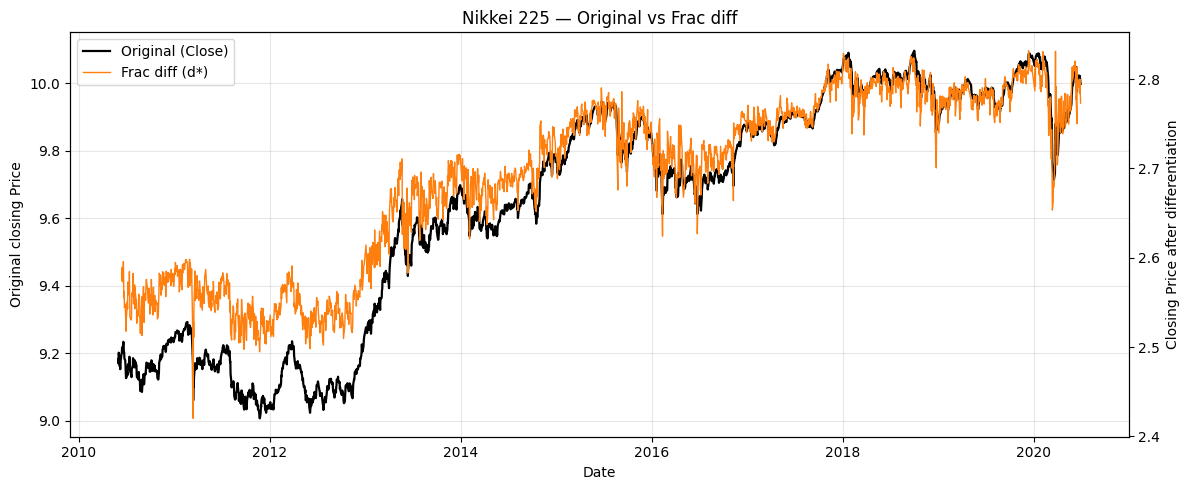

In [14]:
# Combined visualization: original vs diff vs frac diff 
plot_close_vs_frac("S&P 500 — Original vs Frac diff", sp500)
plot_close_vs_frac("DAX — Original vs Frac diff", dax)
plot_close_vs_frac("Nikkei 225 — Original vs Frac diff", nikkei)

## Saving the updated time series

In [15]:
for name, df in {"sp500": sp500, "dax": dax, "nikkei": nikkei}.items():
    joblib.dump(df, f"{name}_updated.pkl")